# Blasius boundary layer

See 
https://github.com/weymouth/NumericalPython/blob/main/05SciPy.ipynb

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_laminar as SANDwake3D

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
#?solve_ivp



$$
\delta(x) = \sqrt{\frac{\nu x}{U}}
$$

$$
\eta = \frac{y}{\delta(x)} = y \sqrt{\frac{U}{\nu x}}
$$

$$
Re_x = \frac{Ux}{\nu}
$$

$$
v = \frac{1}{2} \sqrt{\frac{\nu U}{x}} \left( \eta f' - f \right)
$$

Blasius boundary layer equation
$$
\frac{1}{2} f f'' + f''' = 0
$$

$$
f'(\infty) = 1
$$

$$
f(0) = f'(0) = 0
$$

In [3]:
# Solve the Blasius boundary layer equation
def blasius(t,C0):
    return solve_ivp(lambda t,y: np.array([y[1],y[2],-0.5*y[0]*y[2]]), 
                     np.array([0,t[-1]]), np.array([0,0,C0]), t_eval = t) #.y[1]

#C0 = 1 # guess
C0 = fsolve(lambda C0: blasius([20],C0).y[1][-1]-1,x0=1)[0] # solve!
print(C0)

<ipython-input-3-6445658b202a>:4: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array([0,t[-1]]), np.array([0,0,C0]), t_eval = t) #.y[1]


0.3320022351078443


In [4]:
print("Blasius C_F sqrt(Re) = {:.3f}".format(4*C0))

Blasius C_F sqrt(Re) = 1.328


In [5]:
getReX = lambda Uinf, x, nu: 1.0*Uinf*x/nu

find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

def getUVfromBlasius(x, yvec, Uinf, nu, C0):
    ReX = Uinf*x/nu
    #print(ReX)
    eta = yvec*np.sqrt(Uinf/(nu*x))
    fblasius = blasius(eta,C0)
    u = fblasius.y[1]
    v = 0.5*(eta*fblasius.y[1] - fblasius.y[0])*np.sqrt(nu*Uinf/x)
    return u, v

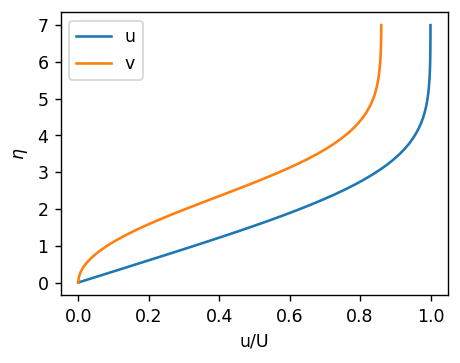

In [6]:
# Plot the results
eta = np.linspace(0,7,51)
fblasius = blasius(eta,C0)

ReX = 1
u = fblasius.y[1]
v = 0.5*(eta*fblasius.y[1] - fblasius.y[0])/np.sqrt(ReX)

plt.figure(figsize=(4,3), dpi=125)
#plt.axvline(0.86,linestyle='--',lw=0.5)
plt.plot(u,eta, label='u')
plt.plot(v,eta, label='v')
plt.xlabel('u/U')
plt.ylabel(r'$\eta$')
plt.legend()
#plt.ylabel('z',rotation=0);

In [7]:
# Set up mesh and BL parameters
Uinf = 1.0
nu   = 0.1

# y-z mesh 
Ny   = 201
ymax = 20
yvec = np.linspace(0,ymax,Ny)

Nz=21
zvec = np.linspace(-1,1,Nz)

# x grid
xvecplot = [40, 50, 80]
#xvecplot = [100, 110, 120, 130]

Text(0, 0.5, 'y')

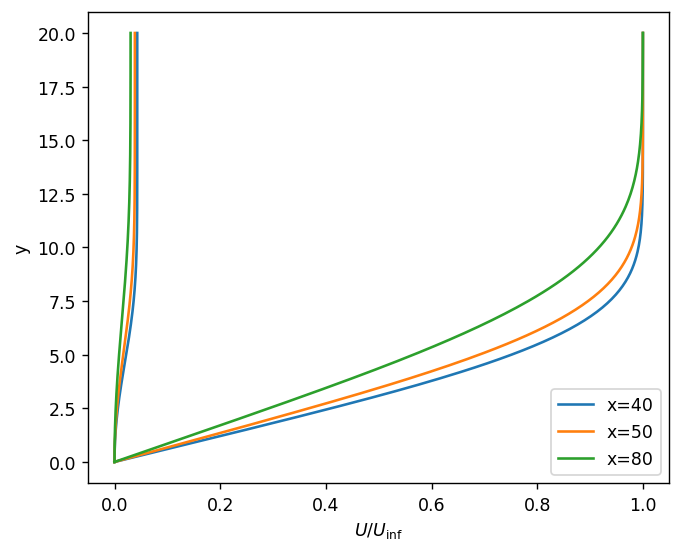

In [8]:
plt.figure(figsize=(6,5), dpi=125)

for x in xvecplot:
    u, v = getUVfromBlasius(x, yvec, Uinf, nu, C0)
    l = plt.plot(u, yvec, label=f'x={x}')
    plt.plot(v, yvec, color=l[0].get_color())
plt.legend()
plt.xlabel('$U/U_\inf$')
plt.ylabel('y')

## Set up RANS

In [9]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'dirichlet', 'value':0.0}
ubc['yhi'] = {'type':'dirichlet', 'value':Uinf}
ubc['zlo'] = {'type':'neumann', 'value':0.0}
ubc['zhi'] = {'type':'neumann', 'value':0.0}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':0.0}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'dirichlet', 'value':0.0}
wbc['yhi'] = {'type':'dirichlet', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'dirichlet', 'value':0.0}

allbc = {'u':ubc, 'v':vbc, 'w':wbc}

In [10]:
dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(dy)
print(dz)

0.1
0.1


In [11]:
# Set up initial conditions
ym, zm = np.meshgrid(yvec, zvec)

u0, v0 = getUVfromBlasius(xvecplot[0], yvec, Uinf, nu, C0)

Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
for iy in range(Ny):
    Uinit[iy, :] = u0[iy]
    Vinit[iy, :] = v0[iy]
Winit  = np.zeros((Ny, Nz))

phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit

In [12]:
# Set parameters
params = {}
params['nu']=nu

In [13]:
dx  = 5
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = xvecplot
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.laminar_eqns, 
                             verbose=True, maxiter=50, tol=1.0E-4)

x = 45.0 dx = 5.0
0 {'u': 1.036851167765654, 'v': 2.3017614005333176, 'w': 0.0}
1 {'u': 0.22609738171751087, 'w': 0.0, 'v': 2.2555296200154777}
2 {'u': 0.23351237331241342, 'w': 0.0, 'v': 0.4902752322910075}
3 {'u': 0.047944786596207455, 'w': 0.0, 'v': 0.5065648623698908}
4 {'u': 0.05456324732422472, 'w': 0.0, 'v': 0.10427100730754467}
5 {'u': 0.010082195512935571, 'w': 0.0, 'v': 0.11844484702517097}
6 {'u': 0.012895419952814631, 'w': 0.0, 'v': 0.021955014214426753}
7 {'u': 0.002090139634632518, 'w': 0.0, 'v': 0.027998419407138417}
8 {'u': 0.003064809281709625, 'w': 0.0, 'v': 0.0045546311221964664}
9 {'u': 0.0004237870469070263, 'w': 0.0, 'v': 0.006654058708024395}
10 {'u': 0.0007311267983675929, 'w': 0.0, 'v': 0.0009240447875717339}
11 {'u': 8.308492448691038e-05, 'w': 0.0, 'v': 0.0015872312376139248}
12 {'u': 0.00017495901145288508, 'w': 0.0, 'v': 0.00018129788046856809}
13 {'u': 1.545402243541305e-05, 'w': 0.0, 'v': 0.0003797916802132052}
14 {'u': 4.199149771909758e-05, 'w': 0.0, 'v

40
1.231739972594079e-16 5.412835519553525e-18
50
0.0010470437617022918 0.0032661517904099845
80
0.003736048169621401 0.0010162999418310054


Text(0, 0.5, 'y')

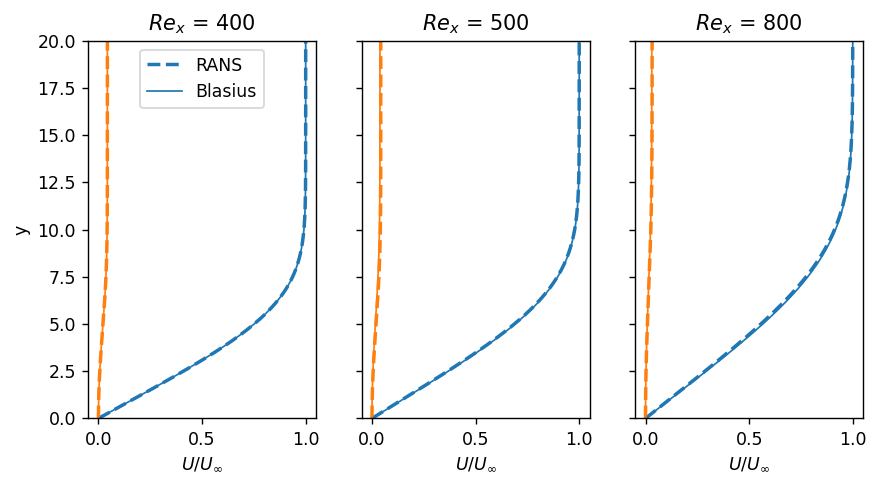

In [14]:
fig, axs = plt.subplots(1, len(xvecplot), figsize=(8,4), dpi=125, sharey=True)
for ix, x in enumerate(xvecplot):
    ixRANS = find_nearest(xvec, x) 
    lu = axs[ix].plot(np.mean(phi['u'][ixRANS,:,:], axis=1), yvec, '--', lw=2, label='RANS')
    lv = axs[ix].plot(np.mean(phi['v'][ixRANS,:,:], axis=1), yvec, '--', lw=2)
    
    print(x)
    # Exact solution
    u, v = getUVfromBlasius(x, yvec, Uinf, nu, C0)
    axs[ix].plot(u, yvec, '-', color=lu[0].get_color(), lw=1, label='Blasius')
    axs[ix].plot(v, yvec, '-', color=lv[0].get_color(), lw=1)
    
    Udiff = np.sum(np.abs(np.mean(phi['u'][ixRANS,:,:], axis=1) - u))/Ny
    Vdiff = np.sum(np.abs(np.mean(phi['v'][ixRANS,:,:], axis=1) - v))/Ny
    print(Udiff, Vdiff)
    #print(np.mean(phi['v'][ix,:,:], axis=1) - v)
    
    axs[ix].set_title(r'$Re_x$ = %0.0f'%getReX(Uinf, x, nu))
    axs[ix].set_ylim([min(yvec), max(yvec)])
    axs[ix].set_xlabel(r'$U/U_\infty$')
    
axs[0].legend()
axs[0].set_ylabel('y')